In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.naive_bayes import BernoulliNB, GaussianNB, MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [3]:
dataset = pd.read_csv(r"C:\Users\Windows 10\OneDrive\Desktop\ai lab task\tested.csv")

Converting Object columns into Int columns

In [4]:
data = dataset.fillna(dataset.mode().iloc[0])

In [5]:
cat_columns = data.select_dtypes(include=['object']).columns
data[cat_columns] = data[cat_columns].apply(lambda col: pd.factorize(col)[0])

In [6]:
X = data.iloc[:, 0:-1]
y = data.iloc[:, -1]

#Splitting Data into train and test

In [7]:
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.3)

In [8]:
def evaluate_model(model, name):
    model.fit(X_train, Y_train)
    pred = model.predict(X_test)

    acc = metrics.accuracy_score(Y_test, pred)
    pre = metrics.precision_score(Y_test, pred, average='weighted')
    rec = metrics.recall_score(Y_test, pred, average='weighted')
    f1 = metrics.f1_score(Y_test, pred, average='weighted')

    print(f"\n{name} Results:")
    print("Accuracy:", acc)
    print("Precision:", pre)
    print("Recall:", rec)
    print("F1 Score:", f1)

    return acc, pre, rec, f1


Applying Different Classifiers

In [9]:
b_acc, b_pre, b_rec, b_f1 = evaluate_model(BernoulliNB(), "Bernoulli")
r_acc, r_pre, r_rec, r_f1 = evaluate_model(RandomForestClassifier(), "Random Forest")
g_acc, g_pre, g_rec, g_f1 = evaluate_model(GaussianNB(), "Gaussian")
d_acc, d_pre, d_rec, d_f1 = evaluate_model(DecisionTreeClassifier(), "Decision Tree")
m_acc, m_pre, m_rec, m_f1 = evaluate_model(MultinomialNB(), "Multinomial")
k_acc, k_pre, k_rec, k_f1 = evaluate_model(KNeighborsClassifier(), "KNN")

c:\Users\Windows 10\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Bernoulli Results:
Accuracy: 0.5873015873015873
Precision: 0.4734811165845649
Recall: 0.5873015873015873
F1 Score: 0.4859896155138586

Random Forest Results:
Accuracy: 0.7222222222222222
Precision: 0.7202825745682888
Recall: 0.7222222222222222
F1 Score: 0.7084506644846364

Gaussian Results:
Accuracy: 0.42857142857142855
Precision: 0.633600230615156
Recall: 0.42857142857142855
F1 Score: 0.452666108842348

Decision Tree Results:
Accuracy: 0.6984126984126984
Precision: 0.7059292643328984
Recall: 0.6984126984126984
F1 Score: 0.6974436631402819

Multinomial Results:
Accuracy: 0.4603174603174603
Precision: 0.7314534142978328
Recall: 0.4603174603174603
F1 Score: 0.4916478464886084

KNN Results:
Accuracy: 0.5396825396825397
Precision: 0.48097572362278246
Recall: 0.5396825396825397
F1 Score: 0.4843511792664335


Plotting Line Graph

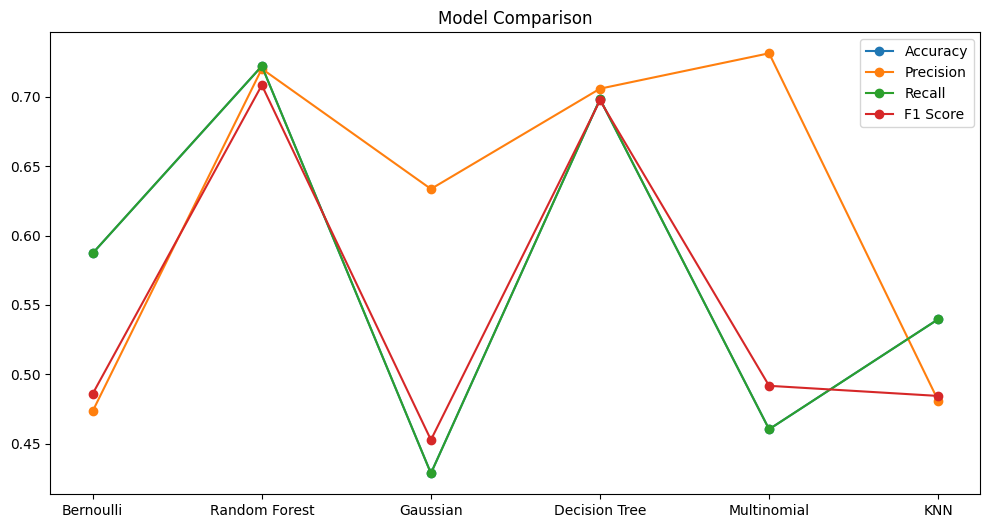

In [10]:
models = ['Bernoulli', 'Random Forest', 'Gaussian', 'Decision Tree', 'Multinomial', 'KNN']

accuracy = [b_acc, r_acc, g_acc, d_acc, m_acc, k_acc]
precision = [b_pre, r_pre, g_pre, d_pre, m_pre, k_pre]
recall = [b_rec, r_rec, g_rec, d_rec, m_rec, k_rec]
f1_scores = [b_f1, r_f1, g_f1, d_f1, m_f1, k_f1]

plt.figure(figsize=(12,6))
plt.plot(models, accuracy, marker='o', label='Accuracy')
plt.plot(models, precision, marker='o', label='Precision')
plt.plot(models, recall, marker='o', label='Recall')
plt.plot(models, f1_scores, marker='o', label='F1 Score')

plt.title("Model Comparison")
plt.legend()
plt.show()


Plotting Bar Graph

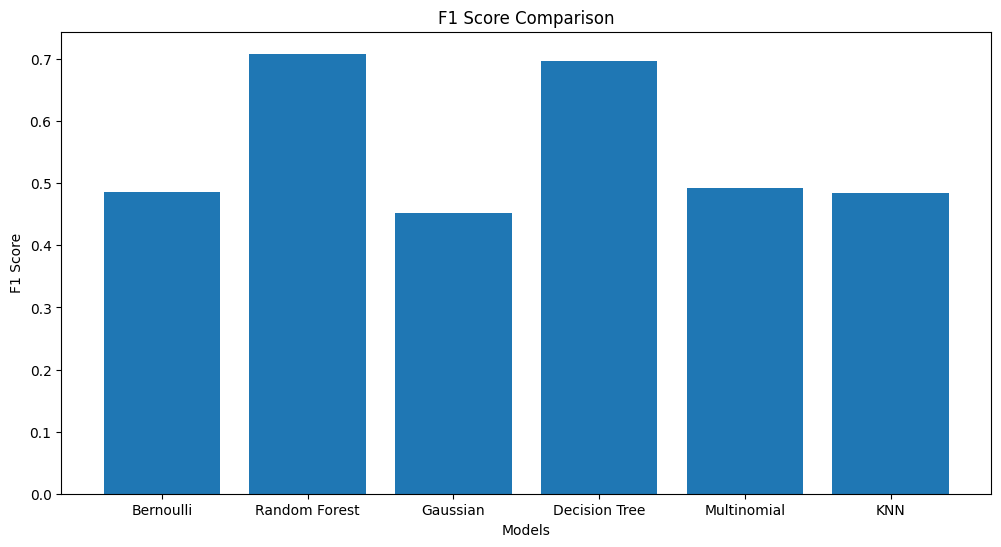

In [11]:
plt.figure(figsize=(12,6))
plt.bar(models, f1_scores)

plt.xlabel("Models")
plt.ylabel("F1 Score")
plt.title("F1 Score Comparison")
plt.show()